# Installation

In [1]:
# run this cell to install pycaret in Google Colab
#!pip install pycaret

In [2]:
# If you are using Jupyter notebook, you can pip install pycaret using jupyter notebook or command line
# pip install pycaret

In [3]:
from pycaret.utils import version
version()

'3.3.2'

In [96]:
# download font thai, update registry
import matplotlib as mpl
!wget https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf
mpl.font_manager.fontManager.addfont('thsarabunnew-webfont.ttf') # Ensuring matplotlib recognizes the font
mpl.rc('font', family='TH Sarabun New') # Setting the default font to TH Sarabun New

--2024-12-07 04:34:42--  https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Phonbopit/sarabun-webfont/master/fonts/thsarabunnew-webfont.ttf [following]
--2024-12-07 04:34:43--  https://raw.githubusercontent.com/Phonbopit/sarabun-webfont/master/fonts/thsarabunnew-webfont.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 98308 (96K) [application/octet-stream]
Saving to: ‘thsarabunnew-webfont.ttf’

thsarabunnew-webfon 100%[===================>]  96.00K  --.-KB/s    in 0.02s   

2024-12-07 04:34:43 (3.97 MB/s) - ‘t

# 1. Importing Dataset

In [97]:
import pandas as pd
from pycaret.datasets import get_data
data = pd.read_csv('สำรวจการใช้ Smartphone (Responses) - Form Responses 1.csv')

In [78]:
data

,Timestamp,เพศของผู้ตอบแบบสอบถาม,ช่วงอายุของผู้ตอบแบบสอบถาม,อาชีพของผู้ตอบแบบสอบถาม,ช่วงเงินเดือนของผู้ตอบแบบสอบถาม,ปัจจุบันท่านใช้สมาร์ทโฟนระบบปฎิบัติการใด,ท่านใช้สมาร์ทโฟนในการทำอะไรมากที่สุด [เล่นเกม],ท่านใช้สมาร์ทโฟนในการทำอะไรมากที่สุด [เล่นโซเชี่ยลมีเดีย],ท่านใช้สมาร์ทโฟนในการทำอะไรมากที่สุด [ดูหนัง ฟังเพลง],ท่านใช้สมาร์ทโฟนในการทำอะไรมากที่สุด [ถ่ายรูป ถ่ายวิดีโอ],หากท่านซื้อสมาร์ทโฟนเครื่องใหม่ จะใช้เลือกซื้อสมาร์ทโฟนแบรนด์ใด,จากข้อที่แล้ว เนื่องจากสาเหตุใด
0,8/17/2024 15:04:18,ชาย,21-25 ปี,ข้าราชการ,"20,001-30,000 บาท",IOS,บ่อยครั้ง,บ่อยที่สุด,บ่อยครั้ง,ปานกลาง,ยังไม่รู้,รอดูอนาคต
1,1/13/2024 15:02:46,หญิง,31-35 ปี,ข้าราชการ,"20,001-30,000 บาท",IOS,น้อยที่สุด,บ่อยครั้ง,บ่อยครั้ง,บ่อยครั้ง,Iphone,ความเร็ว
2,1/13/2024 15:03:52,ชาย,26-30 ปี,ข้าราชการ,"20,001-30,000 บาท",Android,ปานกลาง,ค่อนข้างน้อย,ปานกลาง,น้อยที่สุด,Iphone,ในนี้มืดจังเลยนะฮะ
3,8/17/2024 15:03:33,ชาย,21-25 ปี,นักศึกษา,"น้อยกว่า 20,000 บาท",IOS,ค่อนข้างน้อย,บ่อยครั้ง,ปานกลาง,บ่อยครั้ง,Iphone,ถนัดและสะดวกเพราะใช้มานาน รู้เกี่ยวกับฟังก์ชัน...
4,8/17/2024 15:50:27,ชาย,31-35 ปี,ข้าราชการ,"20,001-30,000 บาท",Android,ปานกลาง,ปานกลาง,ปานกลาง,ค่อนข้างน้อย,Samsung,ใช้ง่าย
...,...,...,...,...,...,...,...,...,...,...,...,...
64,1/13/2024 15:02:35,ชาย,36-40 ปี,เอกชน,"มากกว่า 60,000 บาท",IOS,น้อยที่สุด,บ่อยครั้ง,บ่อยที่สุด,บ่อยครั้ง,Iphone,It is important that smartphones are stable.
65,8/17/2024 15:04:55,หญิง,31-35 ปี,เอกชน,"50,001-60,000 บาท",IOS,น้อยที่สุด,บ่อยที่สุด,บ่อยครั้ง,ปานกลาง,ยังไม่รู้,ยังคิดไม่ออก
66,8/17/2024 15:02:56,ชาย,31-35 ปี,เอกชน,"มากกว่า 60,000 บาท",IOS,ค่อนข้างน้อย,บ่อยที่สุด,บ่อยครั้ง,ปานกลาง,Samsung,ความเคยชิน
67,8/17/2024 15:03:52,ชาย,31-35 ปี,เอกชน,"มากกว่า 60,000 บาท",IOS,ปานกลาง,บ่อยครั้ง,ค่อนข้างน้อย,ค่อนข้างน้อย,Iphone,ความสเถียร


# 2. Setting up Environment

In [5]:
setup??

Object `setup` not found.


In [110]:
from pycaret.classification import *
clf1 = setup(data, target = 'ปัจจุบันท่านใช้สมาร์ทโฟนระบบปฎิบัติการใด', session_id=202, ignore_features = ["Timestamp","จากข้อที่แล้ว เนื่องจากสาเหตุใด","หากท่านซื้อสมาร์ทโฟนเครื่องใหม่ จะใช้เลือกซื้อสมาร์ทโฟนแบรนด์ใด"])

,Description,Value
0,Session id,202
1,Target,ปัจจุบันท่านใช้สมาร์ทโฟนระบบปฎิบัติการใด
2,Target type,Binary
3,Target mapping,"Android: 0, IOS: 1"
4,Original data shape,"(69, 12)"
5,Transformed data shape,"(69, 36)"
6,Transformed train set shape,"(48, 36)"
7,Transformed test set shape,"(21, 36)"
8,Ignore features,3
9,Categorical features,8


In [132]:
clf1.X_train_transformed.head()

AttributeError: 'ClassificationExperiment' object has no attribute 'head'

# 3. Compare Models

In [122]:
compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
qda,Quadratic Discriminant Analysis,0.7900,0.4417,0.7900,0.6940,0.7367,0.1417,0.1417,0.2620
lightgbm,Light Gradient Boosting Machine,0.7900,0.2417,0.7900,0.6245,0.6975,0.0000,0.0000,0.3850
dummy,Dummy Classifier,0.7900,0.5000,0.7900,0.6245,0.6975,0.0000,0.0000,0.1470
knn,K Neighbors Classifier,0.7700,0.6083,0.7700,0.6525,0.7041,0.0500,0.0500,0.3040
rf,Random Forest Classifier,0.7700,0.5000,0.7700,0.6205,0.6863,-0.0250,-0.0250,0.3610
et,Extra Trees Classifier,0.7550,0.5500,0.7550,0.6562,0.6998,0.0250,0.0250,0.2810
lr,Logistic Regression,0.7500,0.4750,0.7500,0.6165,0.6752,-0.0500,-0.0500,0.6830
dt,Decision Tree Classifier,0.7450,0.5417,0.7450,0.6775,0.7022,0.0667,0.0744,0.1500
gbc,Gradient Boosting Classifier,0.7350,0.4250,0.7350,0.6756,0.6963,0.0682,0.0704,0.2380
xgboost,Extreme Gradient Boosting,0.7050,0.4250,0.7050,0.6356,0.6644,-0.0197,-0.0242,0.3480


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

QuadraticDiscriminantAnalysis(priors=None, reg_param=0.0,
                              store_covariance=False, tol=0.0001)

# 4. Create Model

In [88]:
et = create_model('et')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8000,1.0000,0.8000,0.6400,0.7111,0.0000,0.0000
1,0.8000,1.0000,0.8000,0.6400,0.7111,0.0000,0.0000
2,0.8000,1.0000,0.8000,0.6400,0.7111,0.0000,0.0000
3,0.8000,1.0000,0.8000,0.6400,0.7111,0.0000,0.0000
4,0.8000,0.5000,0.8000,0.6400,0.7111,0.0000,0.0000
5,0.8000,0.6250,0.8000,0.6400,0.7111,0.0000,0.0000
6,0.8000,1.0000,0.8000,0.6400,0.7111,0.0000,0.0000
7,0.8000,1.0000,0.8000,0.6400,0.7111,0.0000,0.0000
8,0.7500,0.3333,0.7500,0.5625,0.6429,0.0000,0.0000


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [90]:
nb = create_model('nb')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8000,0.5000,0.8000,0.6400,0.7111,0.0000,0.0000
1,0.8000,0.5000,0.8000,0.6400,0.7111,0.0000,0.0000
2,0.8000,0.5000,0.8000,0.6400,0.7111,0.0000,0.0000
3,0.8000,0.5000,0.8000,0.6400,0.7111,0.0000,0.0000
4,0.8000,0.5000,0.8000,0.6400,0.7111,0.0000,0.0000
5,0.6000,0.3750,0.6000,0.6000,0.6000,-0.2500,-0.2500
6,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,0.8000,0.5000,0.8000,0.6400,0.7111,0.0000,0.0000
8,0.7500,0.5000,0.7500,0.5625,0.6429,0.0000,0.0000


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

# 5. Tune Model

In [16]:
tuned_dt = tune_model(dt)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8000,0.8936,0.8000,0.7992,0.7957,0.5645,0.5705
1,0.7733,0.8688,0.7733,0.7707,0.7707,0.5128,0.5147
2,0.8533,0.9258,0.8533,0.8529,0.8516,0.6848,0.6873
3,0.9200,0.9760,0.9200,0.9200,0.9200,0.8313,0.8313
4,0.8400,0.9100,0.8400,0.8430,0.8409,0.6669,0.6679
5,0.8000,0.8763,0.8000,0.8057,0.8015,0.5862,0.5883
6,0.8400,0.8996,0.8400,0.8390,0.8388,0.6583,0.6594
7,0.7600,0.8533,0.7600,0.7581,0.7585,0.4944,0.4952
8,0.8533,0.9222,0.8533,0.8532,0.8518,0.6893,0.6918


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [91]:
tuned_nb = tune_model(nb, optimize = 'AUC') # Pass the trained model object 'lr'

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8000,0.5000,0.8000,0.6400,0.7111,0.0000,0.0000
1,0.8000,0.5000,0.8000,0.6400,0.7111,0.0000,0.0000
2,0.8000,0.5000,0.8000,0.6400,0.7111,0.0000,0.0000
3,0.8000,0.5000,0.8000,0.6400,0.7111,0.0000,0.0000
4,0.8000,0.5000,0.8000,0.6400,0.7111,0.0000,0.0000
5,0.6000,0.3750,0.6000,0.6000,0.6000,-0.2500,-0.2500
6,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,0.8000,0.5000,0.8000,0.6400,0.7111,0.0000,0.0000
8,0.7500,0.5000,0.7500,0.5625,0.6429,0.0000,0.0000


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [25]:
print(tuned_lr)

LogisticRegression(C=1.503, class_weight={}, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=786, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)


# 6. Ensemble Model

In [13]:
bagged_dt = ensemble_model(dt)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8000,0.8501,0.8000,0.7992,0.7957,0.5645,0.5705
1,0.7600,0.8617,0.7600,0.7577,0.7583,0.4875,0.4883
2,0.8267,0.9397,0.8267,0.8273,0.8230,0.6225,0.6292
3,0.9067,0.9539,0.9067,0.9168,0.9077,0.8093,0.8169
4,0.8133,0.8827,0.8133,0.8215,0.8151,0.6162,0.6200
5,0.7733,0.8628,0.7733,0.7707,0.7707,0.5128,0.5147
6,0.7067,0.8073,0.7067,0.7109,0.7083,0.3893,0.3899
7,0.7067,0.8244,0.7067,0.7029,0.6961,0.3605,0.3706
8,0.8000,0.9019,0.8000,0.8000,0.7962,0.5714,0.5774


Processing:   0%|          | 0/6 [00:00<?, ?it/s]

In [14]:
boosted_dt = ensemble_model(dt, method = 'Boosting')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7467,0.7425,0.7467,0.7530,0.7486,0.4759,0.4775
1,0.8133,0.8032,0.8133,0.8133,0.8133,0.6064,0.6064
2,0.7867,0.7496,0.7867,0.7901,0.7781,0.5261,0.5415
3,0.8000,0.8051,0.8000,0.8115,0.8022,0.5914,0.5969
4,0.8000,0.8051,0.8000,0.8115,0.8022,0.5914,0.5969
5,0.7067,0.7035,0.7067,0.7162,0.7095,0.3969,0.3993
6,0.7733,0.7770,0.7733,0.7851,0.7758,0.5369,0.5419
7,0.6533,0.6333,0.6533,0.6498,0.6511,0.2697,0.2701
8,0.7333,0.7222,0.7333,0.7333,0.7333,0.4444,0.4444


Processing:   0%|          | 0/6 [00:00<?, ?it/s]

# 7. Blend Models

In [15]:
lr = create_model('lr', verbose=False)
lda = create_model('lda', verbose=False)
gbc = create_model('gbc', verbose=False)

In [17]:
blender = blend_models(estimator_list=[lr,lda,gbc], method = 'soft')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7867,0.9070,0.7867,0.7845,0.7832,0.5385,0.5421
1,0.8133,0.8808,0.8133,0.8133,0.8133,0.6064,0.6064
2,0.8400,0.9370,0.8400,0.8400,0.8374,0.6538,0.6582
3,0.9333,0.9850,0.9333,0.9341,0.9335,0.8603,0.8607
4,0.8133,0.9085,0.8133,0.8166,0.8144,0.6114,0.6123
5,0.8133,0.8838,0.8133,0.8166,0.8144,0.6114,0.6123
6,0.8000,0.8958,0.8000,0.8015,0.8006,0.5810,0.5812
7,0.7467,0.8496,0.7467,0.7440,0.7441,0.4633,0.4649
8,0.8533,0.9415,0.8533,0.8532,0.8518,0.6893,0.6918


Processing:   0%|          | 0/6 [00:00<?, ?it/s]

In [18]:
blender.estimators_

[LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                    intercept_scaling=1, l1_ratio=None, max_iter=1000,
                    multi_class='auto', n_jobs=None, penalty='l2',
                    random_state=786, solver='lbfgs', tol=0.0001, verbose=0,
                    warm_start=False),
 LinearDiscriminantAnalysis(covariance_estimator=None, n_components=None,
                            priors=None, shrinkage=None, solver='svd',
                            store_covariance=False, tol=0.0001),
 GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                            learning_rate=0.1, loss='log_loss', max_depth=3,
                            max_features=None, max_leaf_nodes=None,
                            min_impurity_decrease=0.0, min_samples_leaf=1,
                            min_samples_split=2, min_weight_fraction_leaf=0.0,
                            n_estimators=100, n_iter_no_change=None,
          

# 8. Analyze Model

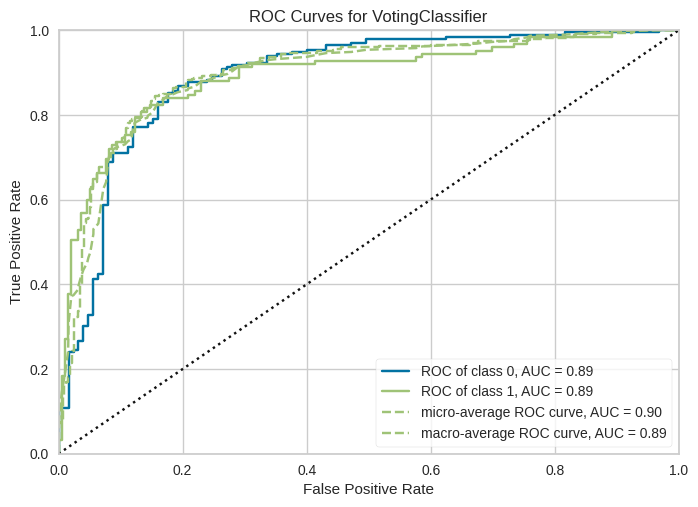

In [23]:
plot_model(blender)

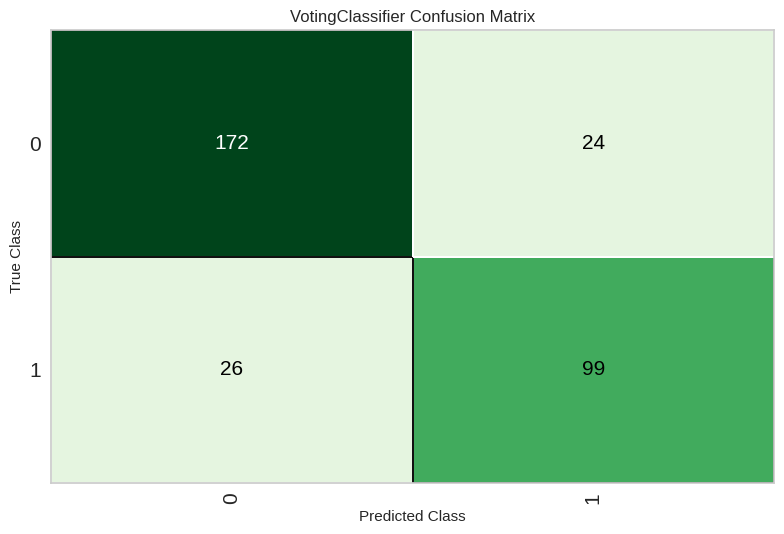

In [24]:
plot_model(blender, plot = 'confusion_matrix')

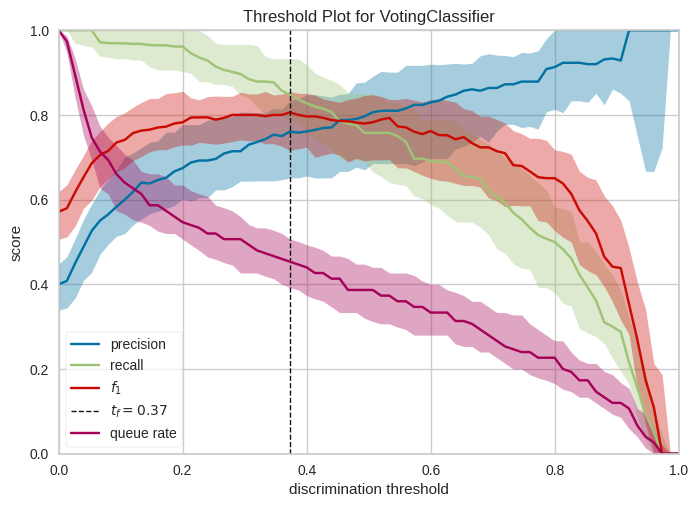

In [26]:
plot_model(blender, plot = 'threshold')

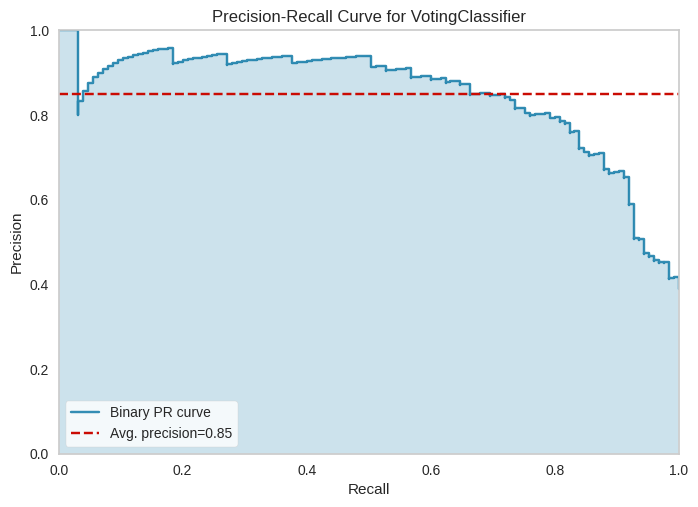

In [27]:
plot_model(blender, plot = 'pr')

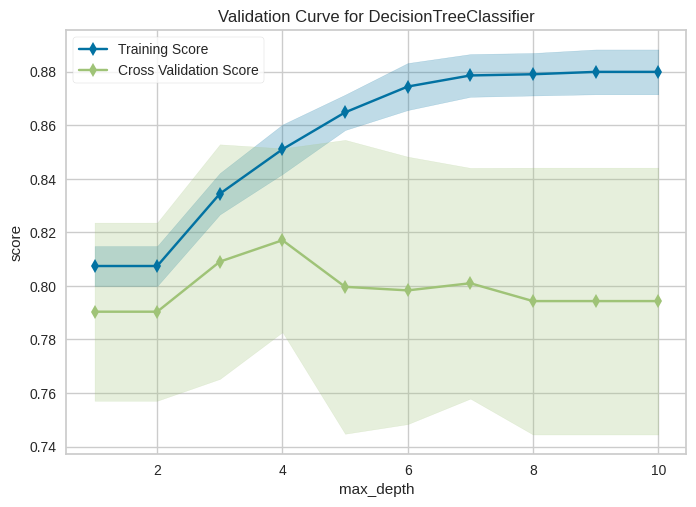

In [28]:
plot_model(tuned_dt, plot = 'vc')

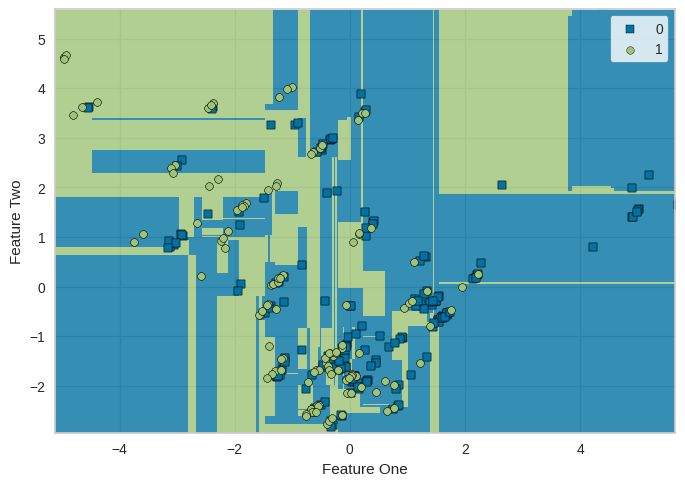

In [29]:
plot_model(dt, plot = 'boundary')

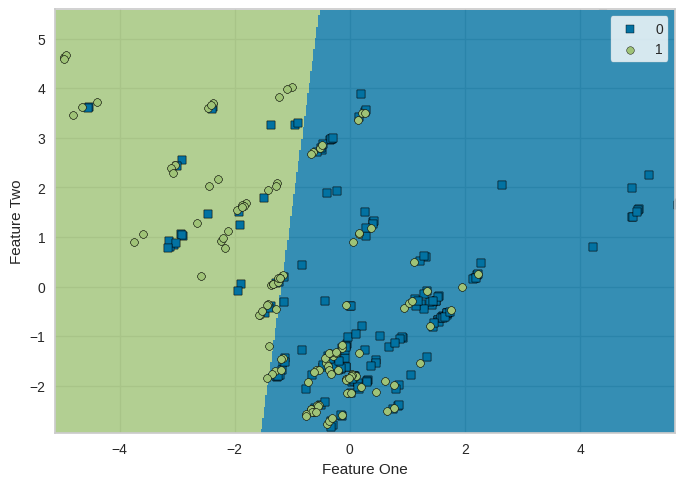

In [32]:
plot_model(tuned_lr, plot = 'boundary')

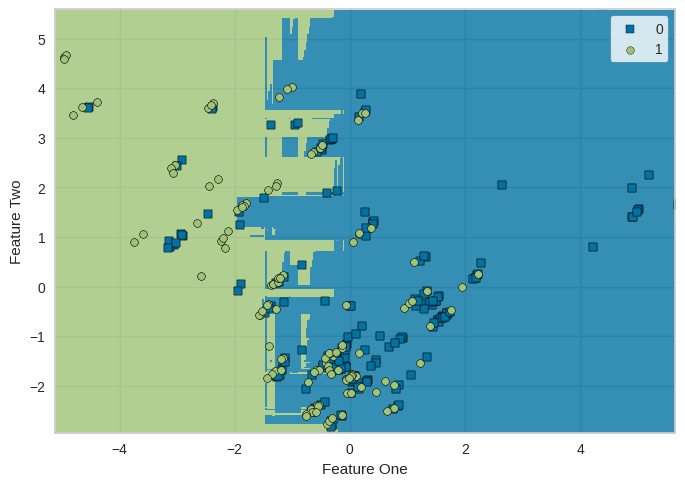

In [33]:
plot_model(blender, plot = 'boundary')

In [35]:
evaluate_model(tuned_lr)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

# 9. Interpret Model

In [111]:
xgboost = clf1.create_model('xgboost')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,0.8000,0.7500,0.8000,0.6400,0.7111,0.0000,0.0000
2,0.8000,0.0000,0.8000,0.6400,0.7111,0.0000,0.0000
3,0.8000,0.0000,0.8000,0.6400,0.7111,0.0000,0.0000
4,0.6000,0.7500,0.6000,0.6000,0.6000,-0.2500,-0.2500
5,0.6000,0.0000,0.6000,0.6000,0.6000,-0.2500,-0.2500
6,0.8000,0.7500,0.8000,0.6400,0.7111,0.0000,0.0000
7,0.4000,0.0000,0.4000,0.5333,0.4571,-0.3636,-0.4082
8,0.7500,0.3333,0.7500,0.5625,0.6429,0.0000,0.0000


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [126]:
tuned_XG = tune_model(xgboost)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8000,1.0000,0.8000,0.6400,0.7111,0.0000,0.0000
1,0.8000,0.5000,0.8000,0.6400,0.7111,0.0000,0.0000
2,0.8000,0.5000,0.8000,0.6400,0.7111,0.0000,0.0000
3,0.8000,0.2500,0.8000,0.6400,0.7111,0.0000,0.0000
4,0.8000,0.5000,0.8000,0.6400,0.7111,0.0000,0.0000
5,0.8000,0.0000,0.8000,0.6400,0.7111,0.0000,0.0000
6,0.8000,0.7500,0.8000,0.6400,0.7111,0.0000,0.0000
7,0.8000,0.0000,0.8000,0.6400,0.7111,0.0000,0.0000
8,0.7500,0.0000,0.7500,0.5625,0.6429,0.0000,0.0000


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


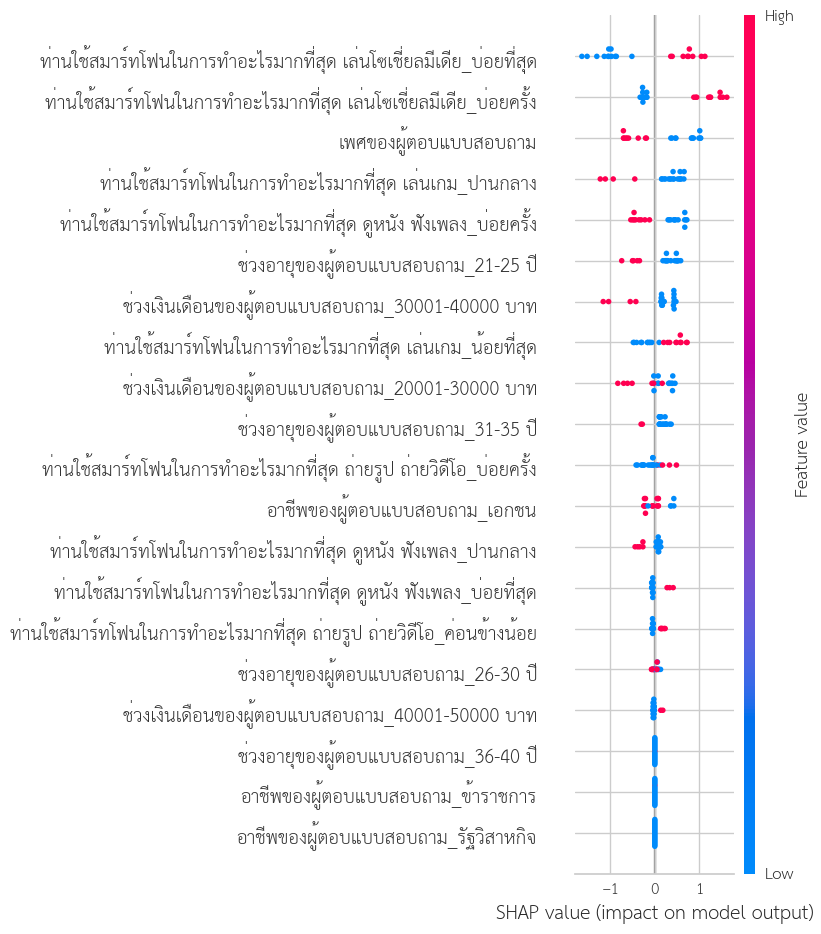

In [125]:
interpret_model(xgboost)

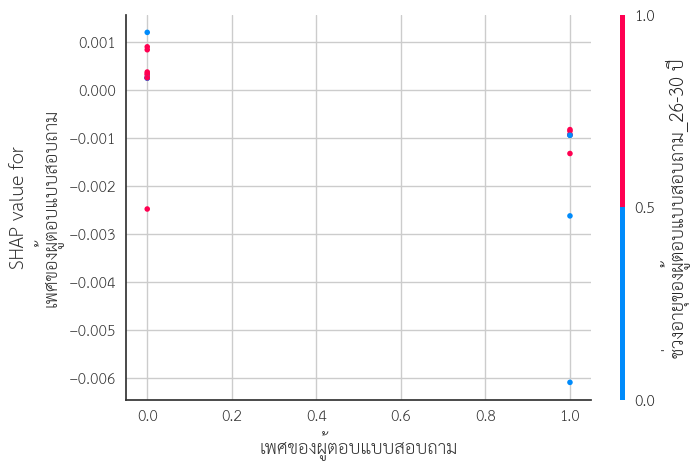

In [115]:
new_var = interpret_model(tuned_XG, plot = 'correlation')


In [116]:
# predict on hold-out/test set
pred_holdout = predict_model(tuned_XG)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.8095,0.6176,0.8095,0.6553,0.7243,0.0000,0.0000


In [117]:
# predict on new data
new_data = data.copy()
new_prediction = predict_model(tuned_XG, data=new_data)
new_prediction

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.7971,0.8299,0.7971,0.6354,0.7071,0.0000,0.0000


,Timestamp,เพศของผู้ตอบแบบสอบถาม,ช่วงอายุของผู้ตอบแบบสอบถาม,อาชีพของผู้ตอบแบบสอบถาม,ช่วงเงินเดือนของผู้ตอบแบบสอบถาม,ท่านใช้สมาร์ทโฟนในการทำอะไรมากที่สุด [เล่นเกม],ท่านใช้สมาร์ทโฟนในการทำอะไรมากที่สุด [เล่นโซเชี่ยลมีเดีย],ท่านใช้สมาร์ทโฟนในการทำอะไรมากที่สุด [ดูหนัง ฟังเพลง],ท่านใช้สมาร์ทโฟนในการทำอะไรมากที่สุด [ถ่ายรูป ถ่ายวิดีโอ],หากท่านซื้อสมาร์ทโฟนเครื่องใหม่ จะใช้เลือกซื้อสมาร์ทโฟนแบรนด์ใด,จากข้อที่แล้ว เนื่องจากสาเหตุใด,ปัจจุบันท่านใช้สมาร์ทโฟนระบบปฎิบัติการใด,prediction_label,prediction_score
0,8/17/2024 15:04:18,ชาย,21-25 ปี,ข้าราชการ,"20,001-30,000 บาท",บ่อยครั้ง,บ่อยที่สุด,บ่อยครั้ง,ปานกลาง,ยังไม่รู้,รอดูอนาคต,IOS,IOS,0.9005
1,1/13/2024 15:02:46,หญิง,31-35 ปี,ข้าราชการ,"20,001-30,000 บาท",น้อยที่สุด,บ่อยครั้ง,บ่อยครั้ง,บ่อยครั้ง,Iphone,ความเร็ว,IOS,IOS,0.8999
2,1/13/2024 15:03:52,ชาย,26-30 ปี,ข้าราชการ,"20,001-30,000 บาท",ปานกลาง,ค่อนข้างน้อย,ปานกลาง,น้อยที่สุด,Iphone,ในนี้มืดจังเลยนะฮะ,Android,IOS,0.8849
3,8/17/2024 15:03:33,ชาย,21-25 ปี,นักศึกษา,"น้อยกว่า 20,000 บาท",ค่อนข้างน้อย,บ่อยครั้ง,ปานกลาง,บ่อยครั้ง,Iphone,ถนัดและสะดวกเพราะใช้มานาน รู้เกี่ยวกับฟังก์ชัน...,IOS,IOS,0.9035
4,8/17/2024 15:50:27,ชาย,31-35 ปี,ข้าราชการ,"20,001-30,000 บาท",ปานกลาง,ปานกลาง,ปานกลาง,ค่อนข้างน้อย,Samsung,ใช้ง่าย,Android,IOS,0.8849
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,1/13/2024 15:02:35,ชาย,36-40 ปี,เอกชน,"มากกว่า 60,000 บาท",น้อยที่สุด,บ่อยครั้ง,บ่อยที่สุด,บ่อยครั้ง,Iphone,It is important that smartphones are stable.,IOS,IOS,0.9046
65,8/17/2024 15:04:55,หญิง,31-35 ปี,เอกชน,"50,001-60,000 บาท",น้อยที่สุด,บ่อยที่สุด,บ่อยครั้ง,ปานกลาง,ยังไม่รู้,ยังคิดไม่ออก,IOS,IOS,0.9012
66,8/17/2024 15:02:56,ชาย,31-35 ปี,เอกชน,"มากกว่า 60,000 บาท",ค่อนข้างน้อย,บ่อยที่สุด,บ่อยครั้ง,ปานกลาง,Samsung,ความเคยชิน,IOS,IOS,0.9026
67,8/17/2024 15:03:52,ชาย,31-35 ปี,เอกชน,"มากกว่า 60,000 บาท",ปานกลาง,บ่อยครั้ง,ค่อนข้างน้อย,ค่อนข้างน้อย,Iphone,ความสเถียร,IOS,IOS,0.9010


In [120]:
interpret_model(tuned_XG, plot = 'reason', observation=0)

In [121]:
interpret_model(tuned_XG, plot = 'reason')

# Learning Resources:

- PyCaret Classification Module : https://www.pycaret.org/classification
- Binary Classification Tutorial (Level Beginner) : https://pycaret.org/clf101/
- Binary Classification Tutorial (Level Intermediate) : https://pycaret.org/clf102/
- Kaggle Titanic Predictions (Video Tutorial) : https://www.youtube.com/watch?v=nqMM6rngNCA